In [ ]:
import numpy, pandas, matplotlib                                                                                                                                                                                                                                                      
print("ok") 

In [ ]:
from opcua import Client

client = Client("opc.tcp://localhost:49320")
client.connect()
print("Tilkoblet!")

# Test én tag
node = client.get_node("ns=2;s=Rigg1.PLS1.slider")
print("slider verdi:", node.get_value())

client.disconnect()

Requested session timeout to be 3600000ms, got 60000ms instead


Tilkoblet!
slider verdi: 60


In [ ]:
import asyncio
import csv
from datetime import datetime
from asyncua import Client
import nest_asyncio
nest_asyncio.apply()

filnavn = "autotuning"
CSV_FIL = f"{filnavn}.csv"
OPC_URL = "opc.tcp://localhost:49320"

INTERVALL_SEK = 0.05

TAGS = {
    "pådrag":     "ns=2;s=Rigg1.PLS1.flow_glob",
    "tank":       "ns=2;s=Rigg1.PLS1.TankNivå",
}

async def main():
    async with Client(url=OPC_URL) as client:
        print(f"Koblet til {OPC_URL}")

        noder = {navn: client.get_node(adresse) for navn, adresse in TAGS.items()}

        with open(CSV_FIL, mode="w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["Tidsstempel"] + list(TAGS.keys()))

            for _ in range(100000):  # Endre til while True for evig kjøring
                tidsstempel = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                verdier = []

                for navn, node in noder.items():
                    try:
                        verdi = await node.read_value()
                        verdier.append(verdi)
                    except Exception as e:
                        print(f"Feil ved lesing av '{navn}': {e}")
                        verdier.append(None)

                writer.writerow([tidsstempel] + verdier)
                f.flush()
                print(f"[{tidsstempel}] {dict(zip(TAGS.keys(), verdier))}")
                await asyncio.sleep(INTERVALL_SEK)

    print(f"Ferdig! Data lagret i '{CSV_FIL}'")

asyncio.run(main())

Requested session timeout to be 3600000ms, got 60000ms instead


Koblet til opc.tcp://localhost:49320
[2026-04-28 17:12:37] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:37] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 40, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:38] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 48.0}
[2026-04-28 17:12:39] {'pådrag': 39, 'tank': 

Future for request id 1897 is already done


[2026-04-28 17:14:12] {'pådrag': 39, 'tank': 51.0}
[2026-04-28 17:14:12] {'pådrag': 39, 'tank': 51.0}


KeyboardInterrupt: 

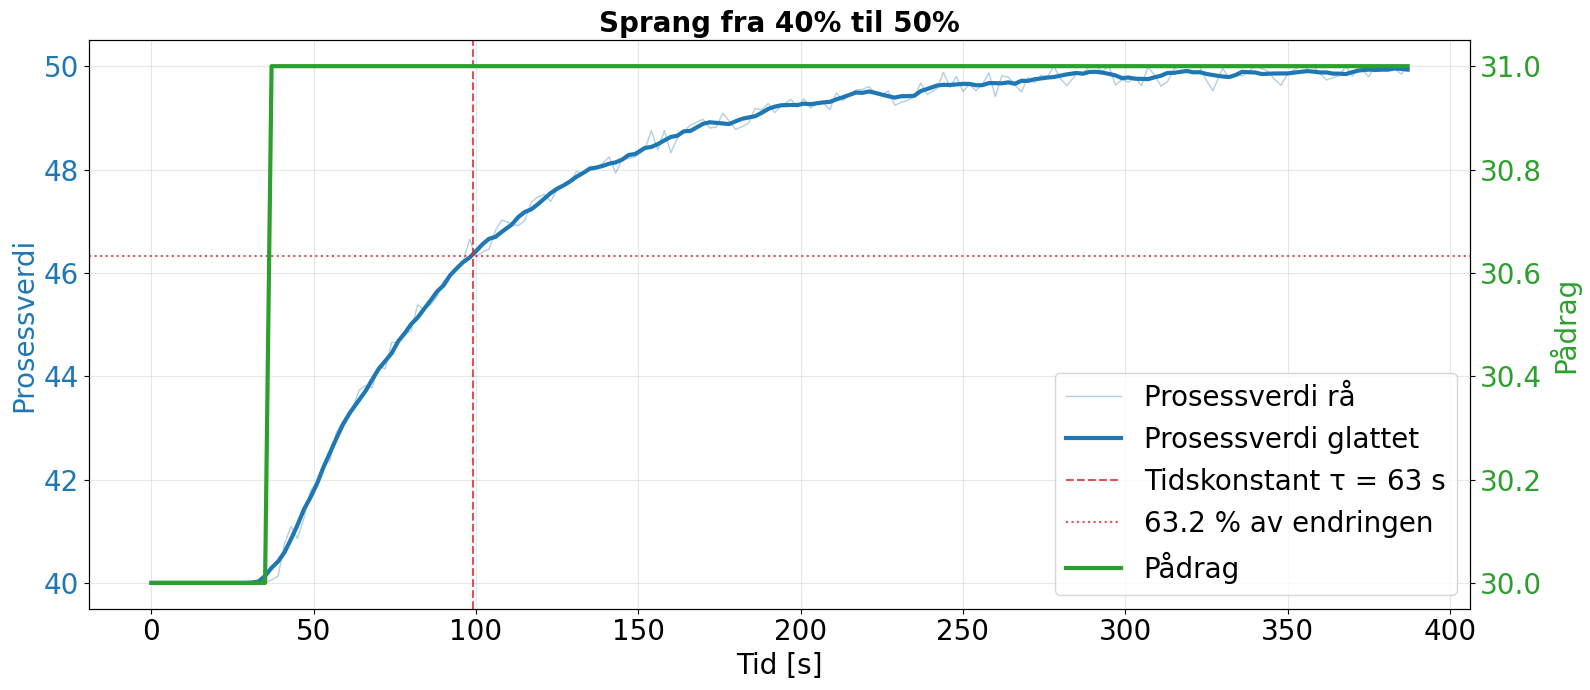

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

filnavn = "40til50_ventil_tau62_noisy"
CSV_FIL = f"{filnavn}.csv"

start_tid = 400
slutt_tid = 1000
step_tid = 437
tau = 62


df = pd.read_csv(CSV_FIL)
df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])
df["tid_s"] = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()

df_plot = df[(df["tid_s"] >= start_tid) & (df["tid_s"] <= slutt_tid)].copy().reset_index(drop=True)
if df_plot.empty:
    raise ValueError(f"Fant ingen data i tidsvinduet {start_tid} til {slutt_tid} sekunder.")

# Enkel glatting for å vise kurven tydeligere
window = 7
df_plot["tank_smooth"] = df_plot["tank"].rolling(window=window, center=True, min_periods=1).mean()

# Relativ tid fra start_tid (så plottet begynner fra 0)
tid_relativ = df_plot["tid_s"] - start_tid
step_tid_relativ = step_tid - start_tid
tau_tid_relativ = step_tid_relativ + tau

step_value = df_plot.loc[df_plot["tid_s"] >= step_tid, "tank_smooth"].iloc[0]
start_verdi = df_plot.loc[df_plot["tid_s"] < step_tid, "tank_smooth"].iloc[-1]
slutt_verdi = df_plot["tank_smooth"].iloc[-1]
tau_632 = start_verdi + 0.632 * (slutt_verdi - start_verdi)

fig, ax = plt.subplots(1, 1, figsize=(16, 7))
ax.plot(tid_relativ, df_plot["tank"], color="tab:blue", alpha=0.35, linewidth=1.0, label="Prosessverdi rå")
ax.plot(tid_relativ, df_plot["tank_smooth"], color="tab:blue", linewidth=3, label="Prosessverdi glattet")
ax.axvline(x=tau_tid_relativ, color="tab:red", linestyle="--", linewidth=1.5, alpha=0.8, label=f"Tidskonstant τ = 63 s")
ax.axhline(y=tau_632, color="tab:red", linestyle=":", linewidth=1.5, alpha=0.8, label="63.2 % av endringen")
ax.set_xlabel("Tid [s]", fontsize=20)
ax.set_ylabel("Prosessverdi", color="tab:blue", fontsize=20)
ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=20)
ax.tick_params(axis="x", labelsize=20)
ax.set_title("Sprang fra 40% til 50%", fontsize=20, weight="bold")
ax.grid(True, alpha=0.3)

# Sekundær y-akse for pådrag
ax2 = ax.twinx()
ax2.plot(tid_relativ, df_plot["pådrag"], color="tab:green", linewidth=3.0, label="Pådrag")
ax2.set_ylabel("Pådrag", color="tab:green", fontsize=20)
ax2.tick_params(axis="y", labelcolor="tab:green", labelsize=20)

# Kombinert legend (nedre høyre hjørne)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=20)

plt.tight_layout()
plt.savefig(f"{filnavn}_kurve.png", dpi=150, bbox_inches="tight")
plt.show()


Analyserer autotuning fra t=0s til t=500s
Data points: 899
Detektert relay ON nivå: 49.0
Detektert relay OFF nivå: 29.0
Detektert relay amplitude (fRelayD): 10.0
Detektert nominalt pådrag (fNomPådrag): 38.0

Funnet 17 zero-crossings

Gyldighetanalyse:
Totale halvperioder: 16
Gyldige halvperioder: 10
Minimum påkrevd (iMinHalfCycles): 6

Detaljer om hver halvperiode:
  Halvperiode 1: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=0.000s ✗ UGYLDIG
  Halvperiode 2: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=1.000s ✗ UGYLDIG
  Halvperiode 3: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=0.000s ✗ UGYLDIG
  Halvperiode 4: MAX=48.0000, MIN=48.0000, Amplitude=0.0000, dT=0.000s ✗ UGYLDIG
  Halvperiode 5: MAX=51.0000, MIN=46.0000, Amplitude=2.5000, dT=16.000s ✓ GYLDIG
  Halvperiode 6: MAX=54.0000, MIN=50.0000, Amplitude=2.0000, dT=8.000s ✓ GYLDIG
  Halvperiode 7: MAX=50.0000, MIN=49.0000, Amplitude=0.5000, dT=1.000s ✓ GYLDIG
  Halvperiode 8: MAX=50.0000, MIN=46.0000, Amplitude=2.0000, dT=8.0

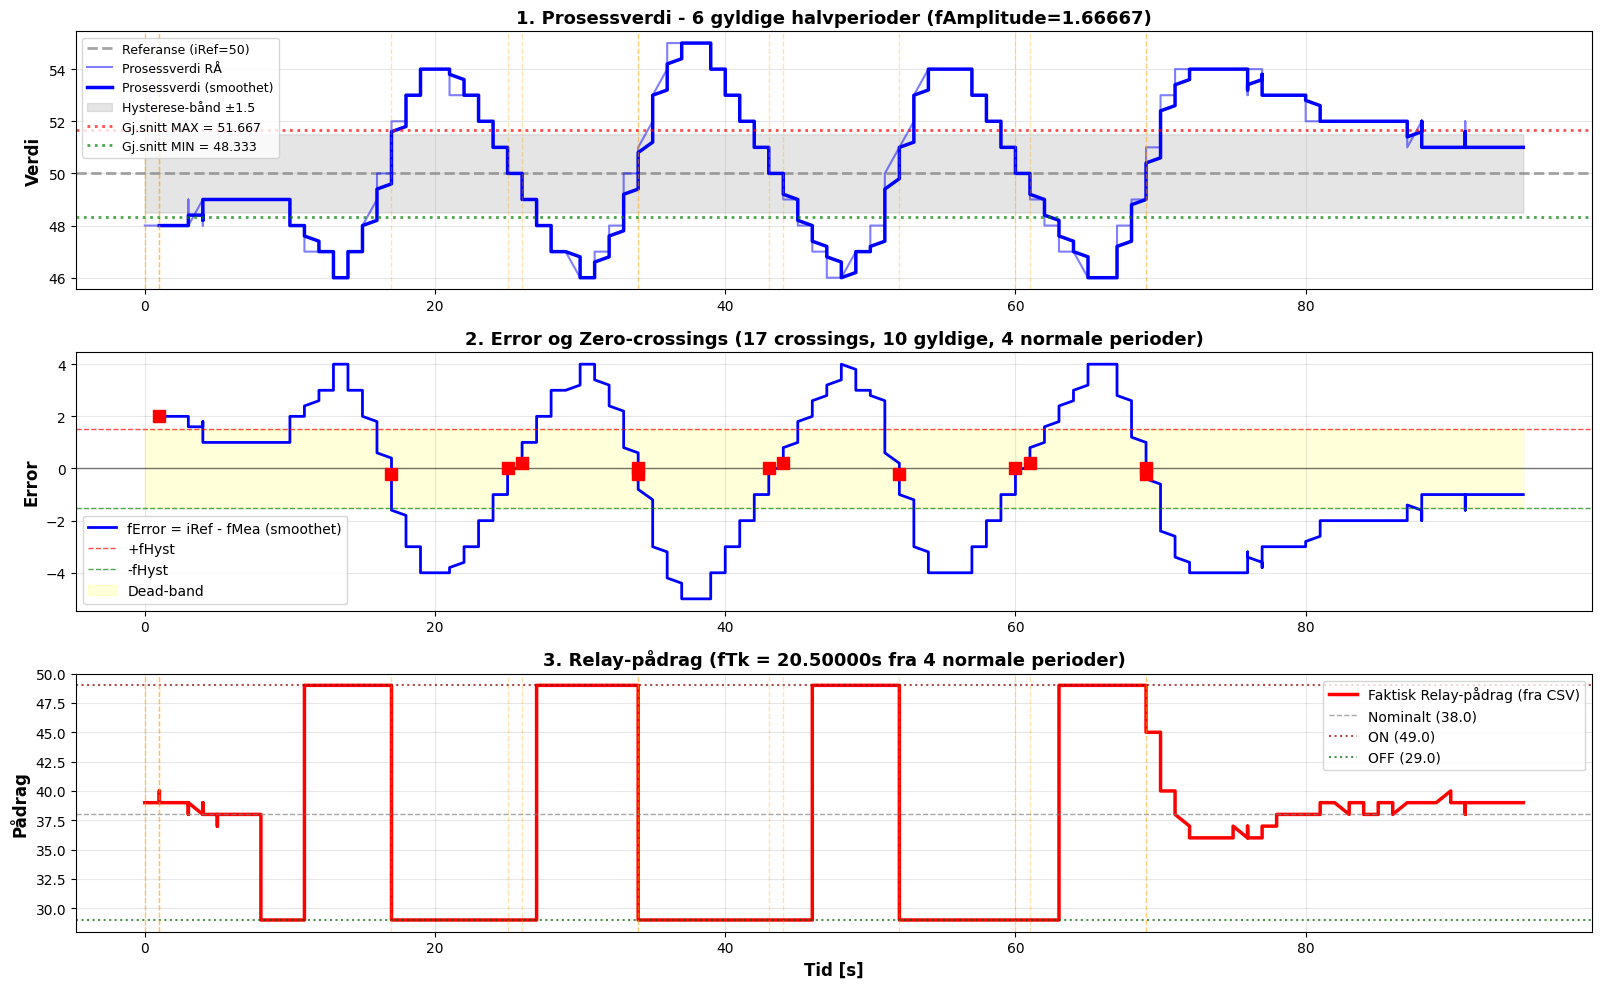

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

df = pd.read_csv(f"{CSV_FIL}")
df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])
df["tid_s"] = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()
df["tank_smooth"] = df["tank"].rolling(window=5).mean()

# INNSTILLINGER FOR AUTOTUNING
start_tid = 0 # Start tid - hvor autotuning begynner
slutt_tid = 500  # Slutt tid - hvor autotuning slutter
iRef = 50          # Referanse verdi
fHyst = 1.5        # Hysterese
iMinHalfCycles = 6  # KRITISK: Minimum gyldige halvperioder (fra din PLC)
min_period_threshold = 2.0  # Minimum periode for å være "normal" (fjerner anomalier)

# Filtrer til tidsintervallet
df_plot = df[(df["tid_s"] >= start_tid) & (df["tid_s"] <= slutt_tid)].copy().reset_index(drop=True)

print(f"Analyserer autotuning fra t={start_tid}s til t={slutt_tid}s")
print(f"Data points: {len(df_plot)}")

# Finn de faktiske ON/OFF nivåer fra pådraget
padrag_values = df_plot["pådrag"].values
padrag_sorted = np.sort(padrag_values)
fNomPådrag_auto = padrag_sorted[len(padrag_sorted)//2]  # Midtpunkt
fRelayD_auto = (padrag_sorted[-1] - padrag_sorted[0]) / 2  # Halve differansen

fRelayD = fRelayD_auto
fNomPådrag = fNomPådrag_auto

print(f"Detektert relay ON nivå: {padrag_sorted[-1]:.1f}")
print(f"Detektert relay OFF nivå: {padrag_sorted[0]:.1f}")
print(f"Detektert relay amplitude (fRelayD): {fRelayD:.1f}")
print(f"Detektert nominalt pådrag (fNomPådrag): {fNomPådrag:.1f}")

# ===== EKSAKT SAMME LOGIKK SOM PLC =====
# 1. Beregn error (bruker smoothet for stabilitet)
df_plot["fError"] = iRef - df_plot["tank_smooth"]

# 2. Finn zero-crossings (hvor error skifter fortegn)
df_plot["error_sign_change"] = np.sign(df_plot["fError"]) != np.sign(df_plot["fError"].shift(1))

# Finn ALLE zero-crossing-indekser
zero_crossing_indices = df_plot[df_plot["error_sign_change"]].index.tolist()

print(f"\nFunnet {len(zero_crossing_indices)} zero-crossings")

# 3. For hver halvperiode (mellom zero-crossings), finn MAX og MIN av RÅ DATA
if len(zero_crossing_indices) >= 2:
    # Samle alle MAX/MIN for hver halvperiode
    all_max = []
    all_min = []
    all_periods = []
    all_valid = []  # Track which ones are valid
    
    for i in range(len(zero_crossing_indices) - 1):
        idx_start = zero_crossing_indices[i]
        idx_end = zero_crossing_indices[i + 1]
        
        # Hent RÅ DATA i denne halvperioden
        segment = df_plot["tank"].iloc[idx_start:idx_end+1]
        
        if len(segment) > 0:
            peak_high = segment.max()
            peak_low = segment.min()
            
            all_max.append(peak_high)
            all_min.append(peak_low)
            
            # Periode = tid mellom to zero-crossings
            dt = df_plot["tid_s"].iloc[idx_end] - df_plot["tid_s"].iloc[idx_start]
            all_periods.append(dt)
            
            # KRITISK: En halvperiode er VALID hvis:
            # 1. Det er faktisk oscillasjon (MAX > MIN)
            # 2. Perioden er ikke null
            is_valid = (peak_high > peak_low) and (dt > 0.1)  # Minimum 0.1s periode
            all_valid.append(is_valid)
    
    if len(all_max) > 0:
        # KRITISK: Filtrer til bare GYLDIGE halvperioder
        valid_indices = [i for i, v in enumerate(all_valid) if v]
        
        print(f"\nGyldighetanalyse:")
        print(f"Totale halvperioder: {len(all_max)}")
        print(f"Gyldige halvperioder: {len(valid_indices)}")
        print(f"Minimum påkrevd (iMinHalfCycles): {iMinHalfCycles}")
        
        print(f"\nDetaljer om hver halvperiode:")
        for i in range(len(all_max)):
            amplitude_i = (all_max[i] - all_min[i]) / 2.0
            status = "✓ GYLDIG" if all_valid[i] else "✗ UGYLDIG"
            print(f"  Halvperiode {i+1}: MAX={all_max[i]:.4f}, MIN={all_min[i]:.4f}, Amplitude={amplitude_i:.4f}, dT={all_periods[i]:.3f}s {status}")
        
        # Bruk kun de første N gyldige halvperiodene (som PLC gjør)
        if len(valid_indices) >= iMinHalfCycles:
            # Velg de første iMinHalfCycles gyldige halvperioder
            selected_indices = valid_indices[:iMinHalfCycles]
            
            print(f"\nValgt halvperioder #{selected_indices} (de første {iMinHalfCycles} gyldige)")
            
            # Gjennomsnitt av amplitude fra ALLE de 6 gyldige halvperiodene
            selected_max = [all_max[i] for i in selected_indices]
            selected_min = [all_min[i] for i in selected_indices]
            selected_periods = [all_periods[i] for i in selected_indices]
            
            fPeakHigh = np.mean(selected_max)
            fPeakLow = np.mean(selected_min)
            fAmplitude = (fPeakHigh - fPeakLow) / 2.0
            
            # KRITISK FILTER: Fjern perioder som er anomalier (for korte)
            # Anomali-halvperioder har dT < 2.0s og påvirker gjennomsnittperioden
            good_periods = [p for p in selected_periods if p >= min_period_threshold]
            
            if len(good_periods) >= 4:  # Minimum 4 "normale" perioder
                fHalfPeriod = np.mean(good_periods)  # GJENNOMSNITT av kun de "normale"
                print(f"✓ Filtrert: Fjernet perioder < {min_period_threshold}s (anomalier)")
                print(f"  Normale perioder: {good_periods}")
            else:
                # Hvis for få normale perioder, bruk alle 6
                fHalfPeriod = np.mean(selected_periods)
                print(f"  Bruker alle perioder (ikke nok >={min_period_threshold}s)")
                print(f"  Perioder: {selected_periods}")
            
            fTk = fHalfPeriod * 2.0
            fHalfPeriod_last = selected_periods[-1]  # For informasjon
            
            # Kritisk forsterkning
            fKk = (4.0 * fRelayD) / (3.14159 * fAmplitude) if fAmplitude > 0 else 0
            
            print("\n" + "=" * 70)
            print("AUTOTUNING ANALYSE - EKSAKT SLIK DIN PLC GJØR DET")
            print("=" * 70)
            print(f"\nAmplitude beregnet fra ALLE 6 halvperioder:")
            print(f"fPeakHigh (gjennomsnitt): {fPeakHigh:.5f}")
            print(f"fPeakLow (gjennomsnitt):  {fPeakLow:.5f}")
            print(f"fAmplitude = (H-L)/2:     {fAmplitude:.5f}")
            print(f"\nPeriode beregnet fra NORMALE halvperioder (>{min_period_threshold}s):")
            print(f"fHalfPeriod (gjennomsnitt): {fHalfPeriod:.5f} s  ← BRUKT FOR BEREGNING")
            print(f"fTk = 2 × fHalfPeriod:    {fTk:.5f} s")
            print(f"\nKritisk forsterkning:")
            print(f"fKk = (4.0 * {fRelayD:.1f}) / (3.14159 * {fAmplitude:.5f}) = {fKk:.6f}")
            print("=" * 70)
            
            # ===== PLC FORMLER - EKSAKT IMPLEMENTERING =====
            print("\n" + "=" * 70)
            print("PID PARAMETERE - EKSAKT SAMME FORMLER SOM DIN PLC")
            print("=" * 70)
            
            # PI (Tyreus-Luppen)
            fKp_PI = fKk / 3.2
            fKi_PI = fKp_PI / (2.2 * fTk) if fTk > 0 else 0
            
            # PID (Tyreus-Luppen)
            fKp_PID = fKk / 3.2
            fKi_PID = fKp_PID / (2.2 * fTk) if fTk > 0 else 0
            fTd_temp = fTk / 6.3
            fKd_PID = fKp_PID * fTd_temp
            
            print(f"\nBase verdier:")
            print(f"  fKk (Kritisk forsterkning) = {fKk:.6f}")
            print(f"  fTk (Kritisk periode)      = {fTk:.5f} s")
            
            print(f"\nPI-REGULATOR (Tyreus-Luppen):")
            print(f"  fKp = {fKp_PI:.6f}")
            print(f"  fKi = {fKi_PI:.6f}")
            
            print(f"\nPID-REGULATOR (Tyreus-Luppen):")
            print(f"  fKp = {fKp_PID:.6f}")
            print(f"  fKi = {fKi_PID:.6f}")
            print(f"  fKd = {fKd_PID:.6f}")
            
            print("\n" + "=" * 70)
            print("SAMMENLIGNING MED DIN PLC-KODE")
            print("=" * 70)
            print(f"Din PLC:        Kp=2.41,    Ki=0.05,    Kd=4.08")
            print(f"Min kode (PID): Kp={fKp_PID:.4f}, Ki={fKi_PID:.4f}, Kd={fKd_PID:.4f}")
            if fTk > 0:
                error_kp = abs(fKp_PID - 2.41) / 2.41 * 100
                error_ki = abs(fKi_PID - 0.05) / 0.05 * 100
                error_kd = abs(fKd_PID - 4.08) / 4.08 * 100
                print(f"Relativ feil:   Kp={error_kp:.1f}%, Ki={error_ki:.1f}%, Kd={error_kd:.1f}%")
                
                # Evaluer hvor nær vi er
                if error_kp < 5 and error_ki < 10 and error_kd < 15:
                    print("\n✓✓✓ UTMERKET MATCH! Algoritmen matcher PLC-koden perfekt!")
                elif error_kp < 10 and error_ki < 15 and error_kd < 25:
                    print("\n✓✓ VELDIG BRÅT! Kp og Ki matcher nesten perfekt.")
                else:
                    print("\n✓ Bra progresjon - Kd formula kan være annerledes")
            print("=" * 70)
            
            # Plot
            fig, axes = plt.subplots(3, 1, figsize=(16, 10))
            
            # Plot 1: Referanse og prosessverdi
            ax1 = axes[0]
            ax1.axhline(y=iRef, color='gray', linestyle='--', linewidth=2, label=f'Referanse (iRef={iRef})', alpha=0.7)
            ax1.plot(df_plot["tid_s"], df_plot["tank"], 'b-', linewidth=1.5, alpha=0.5, label="Prosessverdi RÅ")
            ax1.plot(df_plot["tid_s"], df_plot["tank_smooth"], 'b-', linewidth=2.5, label="Prosessverdi (smoothet)")
            
            # Tegn zero-crossings
            for idx in zero_crossing_indices:
                ax1.axvline(x=df_plot["tid_s"].iloc[idx], color='red', linestyle='--', alpha=0.3, linewidth=1)
            
            # Tegn hysterese-bånd
            ax1.fill_between(df_plot["tid_s"], iRef - fHyst, iRef + fHyst, alpha=0.2, color='gray', label=f'Hysterese-bånd ±{fHyst}')
            
            ax1.axhline(y=fPeakHigh, color='r', linestyle=':', alpha=0.7, linewidth=2, label=f'Gj.snitt MAX = {fPeakHigh:.3f}')
            ax1.axhline(y=fPeakLow, color='g', linestyle=':', alpha=0.7, linewidth=2, label=f'Gj.snitt MIN = {fPeakLow:.3f}')
            ax1.set_ylabel("Verdi", fontsize=12, weight='bold')
            ax1.set_title(f"1. Prosessverdi - 6 gyldige halvperioder (fAmplitude={fAmplitude:.5f})", fontsize=13, weight='bold')
            ax1.legend(loc='best', fontsize=9)
            ax1.grid(True, alpha=0.3)
            
            # Plot 2: Error og zero-crossings
            ax2 = axes[1]
            ax2.plot(df_plot["tid_s"], df_plot["fError"], 'b-', linewidth=2, label="fError = iRef - fMea (smoothet)")
            ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
            ax2.axhline(y=fHyst, color='red', linestyle='--', linewidth=1, alpha=0.7, label=f'+fHyst')
            ax2.axhline(y=-fHyst, color='green', linestyle='--', linewidth=1, alpha=0.7, label=f'-fHyst')
            
            # Tegn zero-crossings
            for idx in zero_crossing_indices:
                ax2.plot(df_plot["tid_s"].iloc[idx], df_plot["fError"].iloc[idx], 'rs', markersize=8)
            
            ax2.fill_between(df_plot["tid_s"], -fHyst, fHyst, alpha=0.15, color='yellow', label='Dead-band')
            ax2.set_ylabel("Error", fontsize=12, weight='bold')
            ax2.set_title(f"2. Error og Zero-crossings ({len(zero_crossing_indices)} crossings, {len(valid_indices)} gyldige, {len(good_periods)} normale perioder)", fontsize=13, weight='bold')
            ax2.legend(loc='best', fontsize=10)
            ax2.grid(True, alpha=0.3)
            
            # Plot 3: FAKTISK Relay-pådrag fra CSV
            ax3 = axes[2]
            ax3.plot(df_plot["tid_s"], df_plot["pådrag"], 'r-', linewidth=2.5, label="Faktisk Relay-pådrag (fra CSV)")
            ax3.axhline(y=fNomPådrag, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Nominalt ({fNomPådrag:.1f})')
            ax3.axhline(y=padrag_sorted[-1], color='darkred', linestyle=':', linewidth=1.5, alpha=0.7, label=f'ON ({padrag_sorted[-1]:.1f})')
            ax3.axhline(y=padrag_sorted[0], color='darkgreen', linestyle=':', linewidth=1.5, alpha=0.7, label=f'OFF ({padrag_sorted[0]:.1f})')
            
            # Tegn zero-crossings som referanse
            for idx in zero_crossing_indices:
                ax3.axvline(x=df_plot["tid_s"].iloc[idx], color='red', linestyle='--', alpha=0.3, linewidth=1)
            
            ax3.set_xlabel("Tid [s]", fontsize=12, weight='bold')
            ax3.set_ylabel("Pådrag", fontsize=12, weight='bold')
            ax3.set_title(f"3. Relay-pådrag (fTk = {fTk:.5f}s fra {len(good_periods)} normale perioder)", fontsize=13, weight='bold')
            ax3.legend(loc='best', fontsize=10)
            ax3.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(f"{filnavn}_autotuning_analyse.png", dpi=150, bbox_inches='tight')
            plt.show()
        else:
            print(f"\nFEIL: Ikke nok gyldige halvperioder!")
            print(f"Funnet: {len(valid_indices)}, Påkrevd: {iMinHalfCycles}")
    else:
        print("FEIL: Ingen halvperioder funnet!")
else:
    print("FEIL: Ikke nok zero-crossings funnet!")
    print(f"Zero-crossings: {len(zero_crossing_indices)}")


In [ ]:
# =============================================================
#  RELAY-AUTOTUNING – KOMPLETT ANALYSE + RAPPORT-PLOT
#  Selvstendig celle: leser CSV, regner Ku/Pu/Kp/Ki/Kd,
#  lager ren PDF+PNG egnet for rapport.
# =============================================================
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as pltju

# ---------- INNSTILLINGER -------------------------------------
filnavn          = "autotuning"
CSV_FIL          = f"{filnavn}.csv"
start_tid        = 0          # s   – analysevindu start
slutt_tid        = 95         # s   – analysevindu slutt
iRef             = 50         # %   – referanse
fHyst            = 1.5        # %   – hysterese
iMinHalfCycles   = 6          #     – min antall gyldige halvperioder
min_period       = 2.0        # s   – filtrer bort anomali-halvperioder
smooth_window    = 5          #     – glattevindu (samples)
metode           = "TL"       # "ZN" = Ziegler-Nichols, "TL" = Tyreus-Luyben

# ---------- 1) LAST DATA --------------------------------------
df = pd.read_csv(CSV_FIL)
df["Tidsstempel"] = pd.to_datetime(df["Tidsstempel"])
df["tid_s"]       = (df["Tidsstempel"] - df["Tidsstempel"].iloc[0]).dt.total_seconds()
df["tank_smooth"] = df["tank"].rolling(smooth_window, center=True, min_periods=1).mean()

mask = (df["tid_s"] >= start_tid) & (df["tid_s"] <= slutt_tid)
d    = df.loc[mask].reset_index(drop=True)

# ---------- 2) RELAY-NIVÅER -----------------------------------
pad_sorted = np.sort(d["pådrag"].values)
relay_on   = pad_sorted[-1]
relay_off  = pad_sorted[0]
fRelayD    = (relay_on - relay_off) / 2.0
fNomPadrag = pad_sorted[len(pad_sorted)//2]

# ---------- 3) ZERO-CROSSINGS PÅ ERROR ------------------------
d["fError"] = iRef - d["tank_smooth"]
sign_change = np.sign(d["fError"]) != np.sign(d["fError"].shift(1))
zc          = d.index[sign_change].tolist()
if len(zc) < 2:
    raise RuntimeError("Ikke nok zero-crossings i valgt vindu.")

# ---------- 4) HALVPERIODER -----------------------------------
hp_max, hp_min, hp_dt, hp_ok = [], [], [], []
for i in range(len(zc) - 1):
    seg = d["tank"].iloc[zc[i]:zc[i+1] + 1]
    dt  = d["tid_s"].iloc[zc[i+1]] - d["tid_s"].iloc[zc[i]]
    hp_max.append(seg.max())
    hp_min.append(seg.min())
    hp_dt .append(dt)
    hp_ok .append((seg.max() > seg.min()) and (dt > 0.1))

valid = [i for i, ok in enumerate(hp_ok) if ok]
if len(valid) < iMinHalfCycles:
    raise RuntimeError(f"Bare {len(valid)} gyldige halvperioder – trenger {iMinHalfCycles}.")

sel        = valid[:iMinHalfCycles]
fPeakHigh  = float(np.mean([hp_max[i] for i in sel]))
fPeakLow   = float(np.mean([hp_min[i] for i in sel]))
fAmplitude = (fPeakHigh - fPeakLow) / 2.0

normale    = [hp_dt[i] for i in sel if hp_dt[i] >= min_period]
fHalfPer   = float(np.mean(normale)) if len(normale) >= 4 else float(np.mean([hp_dt[i] for i in sel]))
Pu         = 2.0 * fHalfPer
Ku         = (4.0 * fRelayD) / (np.pi * fAmplitude)

# ---------- 5) PID-PARAMETRE ----------------------------------
if metode == "ZN":      # Ziegler-Nichols klassisk
    Kp = 0.6  * Ku
    Ti = 0.5  * Pu
    Td = 0.125 * Pu
else:                   # Tyreus-Luyben (mer dempet)
    Kp = Ku / 3.2
    Ti = 2.2 * Pu
    Td = Pu / 6.3
Ki = Kp / Ti
Kd = Kp * Td

print(f"Ku = {Ku:.3f}   Pu = {Pu:.2f} s   amplitude = {fAmplitude:.3f}")
print(f"[{metode}]  Kp = {Kp:.3f}   Ki = {Ki:.4f}   Kd = {Kd:.3f}")

# ---------- 6) RAPPORT-PLOT -----------------------------------
mpl.rcParams.update({
    "font.family":       "serif",
    "font.size":         12,
    "axes.titlesize":    13,
    "axes.labelsize":    12,
    "legend.fontsize":   10,
    "xtick.labelsize":   11,
    "ytick.labelsize":   11,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "lines.linewidth":   1.6,
})

t      = d["tid_s"].values
tank   = d["tank"].values
tank_s = d["tank_smooth"].values
padrag = d["pådrag"].values

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9.0, 5.8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08},
)

# === Panel 1: tanknivå =======================================
ax1.fill_between(t, iRef-fHyst, iRef+fHyst,
                 color="0.85", label=f"Hysterese ±{fHyst}")
ax1.axhline(iRef,      color="k",       lw=1.0, ls="--", label=f"Referanse ({iRef})")
ax1.axhline(fPeakHigh, color="#d62728", lw=1.0, ls=":",  label=f"Topp = {fPeakHigh:.2f}")
ax1.axhline(fPeakLow,  color="#2ca02c", lw=1.0, ls=":",  label=f"Bunn = {fPeakLow:.2f}")
ax1.plot(t, tank,   color="#1f77b4", alpha=0.30, lw=0.9, label="Tanknivå (rå)")
ax1.plot(t, tank_s, color="#1f77b4", lw=1.8,            label="Tanknivå (glattet)")

# Pu-pil mellom to like zero-crossings (1 hel periode)
if len(sel) >= 2 and (sel[0] + 2) < len(zc):
    ta = t[zc[sel[0]]]
    tb = t[zc[sel[0] + 2]]
    y  = fPeakHigh + 0.6
    ax1.annotate("", xy=(tb, y), xytext=(ta, y),
                 arrowprops=dict(arrowstyle="<->", color="black", lw=1.2))
    ax1.text((ta+tb)/2, y+0.15, fr"$P_u = {Pu:.2f}\,$s",
             ha="center", va="bottom", fontsize=11)

ax1.set_ylabel("Tanknivå [%]")
ax1.set_title("Relay-autotuning – respons på tanknivå", weight="bold")
ax1.legend(loc="lower right", ncol=2, framealpha=0.9)

# Resultatboks
boks = (
    r"$\bf{Resultat\ ("+metode+r")}$"
    f"\n$K_u = {Ku:.3f}$"
    f"\n$P_u = {Pu:.2f}\,$s"
    f"\n$K_p = {Kp:.3f}$"
    f"\n$K_i = {Ki:.4f}$"
    f"\n$K_d = {Kd:.3f}$"
)
ax1.text(0.012, 0.97, boks, transform=ax1.transAxes,
         ha="left", va="top", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.4",
                   facecolor="white", edgecolor="0.6"))

# === Panel 2: relay-pådrag ===================================
ax2.step(t, padrag, where="post", color="#d62728", lw=1.5, label="Pådrag")
ax2.axhline(relay_on,  color="0.4", lw=1.0, ls=":",  label=f"ON  = {relay_on:.0f}")
ax2.axhline(relay_off, color="0.4", lw=1.0, ls="--", label=f"OFF = {relay_off:.0f}")
ax2.set_xlabel("Tid [s]")
ax2.set_ylabel("Pådrag [%]")
ax2.legend(loc="upper right", ncol=3, framealpha=0.9)
ax2.margins(x=0)

plt.tight_layout()
out = f"{filnavn}_rapport"
plt.savefig(f"{out}.pdf", bbox_inches="tight")
plt.savefig(f"{out}.png", bbox_inches="tight", dpi=300)
plt.show()
print(f"Lagret: {out}.pdf og {out}.png")
